# Importar librerías

In [1]:
import sys
from pathlib import Path

# encontrar raíz del proyecto (carpeta que contiene "src")
root = Path().resolve()
while not (root / "src").exists():
    root = root.parent

sys.path.append(str(root))

In [2]:
import pandas as pd
import csv
from src.data.load_data import cargar_csv
from src.models.train_models import build_churn_nn
from src.models.model_selection import seleccionar_mejor_modelo
from src.models.predict import get_predictions
from src.evaluation.metrics import evaluate_models, plot_roc_models, confusion_matrices
from sklearn.metrics import roc_auc_score
from src.models.save_model import save_best_model
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
import optuna
import matplotlib.pyplot as plt

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Cargar base de datos

In [3]:
ruta_archivo = '../databases/processed/base_feature_engineering.csv'

In [4]:
archivo = cargar_csv(ruta_archivo)
archivo.head()

,customer_id,churn_label,monthly_spend,total_shipments,customer_tenure_days,days_since_last_purchase,shipments_per_month,spend_per_shipment
0,C001,0,450.5,12,1146,91,0.306122,34.653846
1,C002,0,1200.0,45,1110,300,1.184211,26.086957
2,C003,1,3435.0,8,1097,346,0.212955,381.666667
3,C004,0,890.2,22,1059,278,0.606061,38.704348
4,C005,1,310.0,5,1011,441,0.144092,51.666667


# Modelado

In [5]:
variables = ['monthly_spend', 'total_shipments', 'customer_tenure_days', 'days_since_last_purchase',
             'shipments_per_month', 'spend_per_shipment']
X = archivo[variables]
y = archivo["churn_label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [7]:
pd.merge(archivo['customer_id'], pd.concat([y_test,X_test], axis=1), left_index=True, right_index=True).to_csv('../databases/processed/data_test.csv', sep=',', index=False)

In [8]:
# 2. Escalado de variables numéricas
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# 3. Balanceo con SMOTE (Synthetic Minority Oversampling Technique)
smote = SMOTE(random_state=42, sampling_strategy=0.5)  
# sampling_strategy=0.5 → la clase minoritaria será el 50% de la mayoritaria
X_train, y_train = smote.fit_resample(X_train, y_train)

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
# Modelo base (Logistic Regression)
log_params = {"C":[0.01,0.1,1,10], "penalty":["l1","l2"], "solver":["liblinear"]}
log_model = GridSearchCV(LogisticRegression(max_iter=2000), log_params, cv=cv, scoring="roc_auc")
log_model.fit(X_train,y_train)

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=2000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [12]:
# Random Forest
rf_params = {"n_estimators":[100,200,500], "max_depth":[3,5,10,None], "min_samples_split":[2,5,10], "min_samples_leaf":[1,2,4]}
rf_model = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=cv, scoring="roc_auc")
rf_model.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

In [13]:
# Gradient Boosting
gb_params = {"n_estimators":[100,200], "learning_rate":[0.01,0.05,0.1], "max_depth":[3,4,5]}
gb_model = GridSearchCV(GradientBoostingClassifier(), gb_params, cv=cv, scoring="roc_auc")
gb_model.fit(X_train,y_train)
gb = gb_model.best_estimator_

In [14]:
# XGBoost
xgb_params = {"n_estimators":[100,200,500], "max_depth":[3,4,5], "learning_rate":[0.01,0.05,0.1], "subsample":[0.7,0.8,1],
              "colsample_bytree":[0.7,0.8,1]}
xgb_model = GridSearchCV(XGBClassifier(eval_metric="logloss"), xgb_params, cv=cv, scoring="roc_auc")
xgb_model.fit(X_train,y_train)
xgb = xgb_model.best_estimator_

In [15]:
# SVM
svm_params = {"C":[0.1,1,10], "kernel":["rbf","linear"], "gamma":["scale","auto"]}
svm_model = GridSearchCV(SVC(probability=True), svm_params, cv=cv, scoring="roc_auc")
svm_model.fit(X_train,y_train)
svm = svm_model.best_estimator_

# Entrenamiento redes neuronales

In [16]:
# Red neuronal 1 (MLPClassifier)
mlp_params = {"hidden_layer_sizes":[(16,),(32,),(16,8)], "activation":["relu","tanh"],
              "alpha":[0.0001,0.001,0.01], "learning_rate_init":[0.001,0.01]}
mlp_model = GridSearchCV(MLPClassifier(max_iter=2000), mlp_params, cv=cv, scoring="roc_auc")
mlp_model.fit(X_train,y_train)
mlp = mlp_model.best_estimator_

In [17]:
def objective(trial):
    hidden1 = trial.suggest_int("hidden1", 64, 256)
    hidden2 = trial.suggest_int("hidden2", 32, 128)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    model = build_churn_nn(input_dim=X_train.shape[1], hidden1=hidden1, hidden2=hidden2, dropout=dropout, lr=lr)
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

    model.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=batch_size, callbacks=[early_stop], verbose=0)

    proba = model.predict(X_test).flatten()
    score = roc_auc_score(y_test, proba)
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

best_params = study.best_params

best_nn_model = build_churn_nn(
    input_dim=X_train.shape[1],
    hidden1=best_params["hidden1"],
    hidden2=best_params["hidden2"],
    dropout=best_params["dropout"],
    lr=best_params["lr"]
)
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
history = best_nn_model.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=best_params["batch_size"],
                            callbacks=[early_stop], verbose=1)
best_nn_model.best_score_ = study.best_value

[I 2026-03-06 23:12:40,924] A new study created in memory with name: no-name-6c47d2ee-204b-4a67-bd41-ac88a13921a3



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


[I 2026-03-06 23:12:58,085] Trial 0 finished with value: 0.9800000000000001 and parameters: {'hidden1': 101, 'hidden2': 67, 'dropout': 0.2124603163597478, 'lr': 0.0010681750680852252, 'batch_size': 16}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


[I 2026-03-06 23:13:07,076] Trial 1 finished with value: 0.9349999999999999 and parameters: {'hidden1': 224, 'hidden2': 54, 'dropout': 0.3248483206218573, 'lr': 0.001273319754675005, 'batch_size': 32}. Best is trial 0 with value: 0.9800000000000001.


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000229DCB90F40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


[I 2026-03-06 23:13:13,153] Trial 2 finished with value: 0.905 and parameters: {'hidden1': 180, 'hidden2': 107, 'dropout': 0.33720059505850997, 'lr': 0.006079801279411505, 'batch_size': 32}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


[I 2026-03-06 23:13:26,970] Trial 3 finished with value: 0.965 and parameters: {'hidden1': 168, 'hidden2': 97, 'dropout': 0.4720410117858821, 'lr': 0.0014595635971994974, 'batch_size': 32}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


[I 2026-03-06 23:13:34,469] Trial 4 finished with value: 0.9450000000000001 and parameters: {'hidden1': 195, 'hidden2': 89, 'dropout': 0.1337494255051889, 'lr': 0.0012984997042191164, 'batch_size': 64}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


[I 2026-03-06 23:13:56,964] Trial 5 finished with value: 0.905 and parameters: {'hidden1': 88, 'hidden2': 67, 'dropout': 0.4350524209714718, 'lr': 0.00031019813814736364, 'batch_size': 32}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


[I 2026-03-06 23:14:03,261] Trial 6 finished with value: 0.9400000000000001 and parameters: {'hidden1': 141, 'hidden2': 104, 'dropout': 0.2981927655428456, 'lr': 0.0044267215012158785, 'batch_size': 16}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


[I 2026-03-06 23:14:09,839] Trial 7 finished with value: 0.9249999999999999 and parameters: {'hidden1': 234, 'hidden2': 126, 'dropout': 0.4543778130522579, 'lr': 0.004851445796939675, 'batch_size': 64}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


[I 2026-03-06 23:14:16,679] Trial 8 finished with value: 0.9199999999999999 and parameters: {'hidden1': 84, 'hidden2': 42, 'dropout': 0.2830589013981293, 'lr': 0.004962949912340078, 'batch_size': 32}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


[I 2026-03-06 23:14:22,054] Trial 9 finished with value: 0.94 and parameters: {'hidden1': 194, 'hidden2': 106, 'dropout': 0.3190357720433919, 'lr': 0.002457181698994965, 'batch_size': 16}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


[I 2026-03-06 23:14:36,942] Trial 10 finished with value: 0.98 and parameters: {'hidden1': 126, 'hidden2': 32, 'dropout': 0.1445528738151617, 'lr': 0.0003624600919928603, 'batch_size': 16}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


[I 2026-03-06 23:14:53,930] Trial 11 finished with value: 0.9700000000000001 and parameters: {'hidden1': 124, 'hidden2': 34, 'dropout': 0.14282187012787942, 'lr': 0.00037804639087896385, 'batch_size': 16}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


[I 2026-03-06 23:15:07,908] Trial 12 finished with value: 0.805 and parameters: {'hidden1': 114, 'hidden2': 71, 'dropout': 0.20847778726601612, 'lr': 0.00010675806741347092, 'batch_size': 16}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


[I 2026-03-06 23:15:25,976] Trial 13 finished with value: 0.9650000000000001 and parameters: {'hidden1': 69, 'hidden2': 54, 'dropout': 0.20629474445547955, 'lr': 0.00038681906093435576, 'batch_size': 16}. Best is trial 0 with value: 0.9800000000000001.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


[I 2026-03-06 23:15:42,954] Trial 14 finished with value: 0.985 and parameters: {'hidden1': 110, 'hidden2': 51, 'dropout': 0.1002753245852937, 'lr': 0.0005659531088351308, 'batch_size': 16}. Best is trial 14 with value: 0.985.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


[I 2026-03-06 23:15:54,827] Trial 15 finished with value: 0.98 and parameters: {'hidden1': 102, 'hidden2': 58, 'dropout': 0.21668362171476582, 'lr': 0.0006830419267605638, 'batch_size': 16}. Best is trial 14 with value: 0.985.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


[I 2026-03-06 23:16:09,683] Trial 16 finished with value: 0.995 and parameters: {'hidden1': 139, 'hidden2': 77, 'dropout': 0.10671223956945004, 'lr': 0.000733323871845497, 'batch_size': 16}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


[I 2026-03-06 23:16:30,823] Trial 17 finished with value: 0.95 and parameters: {'hidden1': 146, 'hidden2': 80, 'dropout': 0.10973614713241267, 'lr': 0.00017530754984004996, 'batch_size': 64}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


[I 2026-03-06 23:16:42,876] Trial 18 finished with value: 0.985 and parameters: {'hidden1': 254, 'hidden2': 82, 'dropout': 0.10041577222934937, 'lr': 0.0006495232818640128, 'batch_size': 16}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


[I 2026-03-06 23:16:48,115] Trial 19 finished with value: 0.9199999999999999 and parameters: {'hidden1': 64, 'hidden2': 45, 'dropout': 0.39152821090317214, 'lr': 0.002553418104070083, 'batch_size': 16}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


[I 2026-03-06 23:17:05,219] Trial 20 finished with value: 0.98 and parameters: {'hidden1': 148, 'hidden2': 125, 'dropout': 0.17996048167445589, 'lr': 0.0006999953021311227, 'batch_size': 64}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


[I 2026-03-06 23:17:21,590] Trial 21 finished with value: 0.985 and parameters: {'hidden1': 207, 'hidden2': 81, 'dropout': 0.10109707261110487, 'lr': 0.0007831541419036935, 'batch_size': 16}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


[I 2026-03-06 23:17:40,044] Trial 22 finished with value: 0.9850000000000001 and parameters: {'hidden1': 246, 'hidden2': 91, 'dropout': 0.17001794637241743, 'lr': 0.0005212655688830182, 'batch_size': 16}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


[I 2026-03-06 23:17:47,170] Trial 23 finished with value: 0.925 and parameters: {'hidden1': 167, 'hidden2': 92, 'dropout': 0.15967090357102057, 'lr': 0.00021479452802329526, 'batch_size': 16}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


[I 2026-03-06 23:18:00,246] Trial 24 finished with value: 0.98 and parameters: {'hidden1': 134, 'hidden2': 74, 'dropout': 0.1746648473707246, 'lr': 0.00045981381711095767, 'batch_size': 16}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


[I 2026-03-06 23:18:05,743] Trial 25 finished with value: 0.915 and parameters: {'hidden1': 254, 'hidden2': 115, 'dropout': 0.26676774063904385, 'lr': 0.001880266660792651, 'batch_size': 16}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


[I 2026-03-06 23:18:19,291] Trial 26 finished with value: 0.97 and parameters: {'hidden1': 158, 'hidden2': 58, 'dropout': 0.23409680989655862, 'lr': 0.0004965983422364792, 'batch_size': 16}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


[I 2026-03-06 23:18:36,759] Trial 27 finished with value: 0.975 and parameters: {'hidden1': 105, 'hidden2': 87, 'dropout': 0.1344325583981063, 'lr': 0.00023107262885838615, 'batch_size': 16}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step


[I 2026-03-06 23:18:47,005] Trial 28 finished with value: 0.895 and parameters: {'hidden1': 119, 'hidden2': 97, 'dropout': 0.24961505932805972, 'lr': 0.0009467094556057353, 'batch_size': 64}. Best is trial 16 with value: 0.995.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


[I 2026-03-06 23:18:59,783] Trial 29 finished with value: 0.98 and parameters: {'hidden1': 87, 'hidden2': 64, 'dropout': 0.17765706305970042, 'lr': 0.0009180178956583064, 'batch_size': 16}. Best is trial 16 with value: 0.995.


Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 1.0532 - val_loss: 0.7078
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7618 - val_loss: 0.6603
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4957 - val_loss: 0.6324
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4068 - val_loss: 0.6096
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3415 - val_loss: 0.5969
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3214 - val_loss: 0.5847
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3483 - val_loss: 0.5720
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2911 - val_loss: 0.5586
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3245 - val_loss: 0.5456
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3411 - val_loss: 0.5346
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3554 - val_loss: 0.5289
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3262 - val_lo

# Selección del mejor modelo

In [18]:
models = {"Logistic":log_model, "RandomForest":rf_model, "GradientBoosting":gb_model, "XGBoost":xgb_model,
          "SVM":svm_model,"NeuralNet":mlp_model, 'nn_tf_model':best_nn_model}
results = seleccionar_mejor_modelo(models)[0]
best_model = seleccionar_mejor_modelo(models)[1]

In [19]:
results

,Model,Best_Score
0,nn_tf_model,0.995000
1,RandomForest,0.983939
2,Logistic,0.983939
3,NeuralNet,0.981212
4,XGBoost,0.980758
5,SVM,0.973939
6,GradientBoosting,0.971515


In [20]:
best_model

<Sequential name=sequential, built=True>

In [21]:
y_pred, y_prob = get_predictions(best_model, X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


In [22]:
metrics_df = evaluate_models(models, X_test, y_test)
print(metrics_df)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
              Model  Accuracy  Precision  Recall        F1  ROC_AUC
0      RandomForest  0.939394   1.000000   0.750  0.857143    1.000
1           XGBoost  0.878788   1.000000   0.500  0.666667    1.000
2       nn_tf_model  0.909091   1.000000   0.625  0.769231    0.995
3          Logistic  0.969697   1.000000   0.875  0.933333    0.985
4               SVM  0.848485   0.800000   0.500  0.615385    0.940
5  GradientBoosting  0.878788   1.000000   0.500  0.666667    0.905
6         NeuralNet  0.909091   0.857143   0.750  0.800000    0.890


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


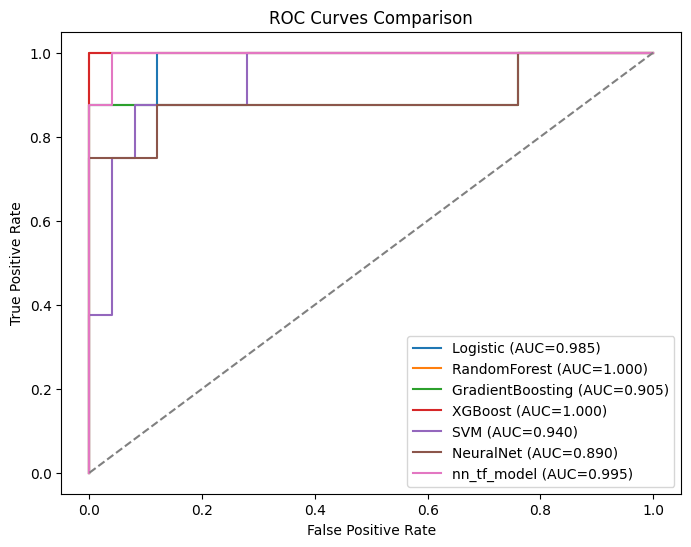

In [23]:
plot_roc_models(models, X_test, y_test)

In [24]:
confusion_matrices(models, X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


{'Logistic': array([[25,  0],
        [ 1,  7]]),
 'RandomForest': array([[25,  0],
        [ 2,  6]]),
 'GradientBoosting': array([[25,  0],
        [ 4,  4]]),
 'XGBoost': array([[25,  0],
        [ 4,  4]]),
 'SVM': array([[24,  1],
        [ 4,  4]]),
 'NeuralNet': array([[24,  1],
        [ 2,  6]]),
 'nn_tf_model': array([[25,  0],
        [ 3,  5]])}

# Importancia de características del Random Forest

In [25]:
pd.Series(rf_model.best_estimator_.feature_importances_, index=X.columns).sort_values(ascending=False)

total_shipments             0.294594
shipments_per_month         0.246860
monthly_spend               0.234720
days_since_last_purchase    0.145395
spend_per_shipment          0.044767
customer_tenure_days        0.033663
dtype: float64

# Resultados red neuronal

In [26]:
proba = best_nn_model.predict(X_test).flatten()
roc_auc_score(y_test, proba)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


0.995

In [27]:
# early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
# model = build_churn_nn(input_dim=X_train.shape[1], hidden1=128, hidden2=64, dropout=0.3, lr=0.001)
# history = model.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[early_stop], verbose=1)
# proba = model.predict(X_test).flatten()
# pred = (proba > 0.5).astype(int)
# roc_auc_score(y_test, proba)

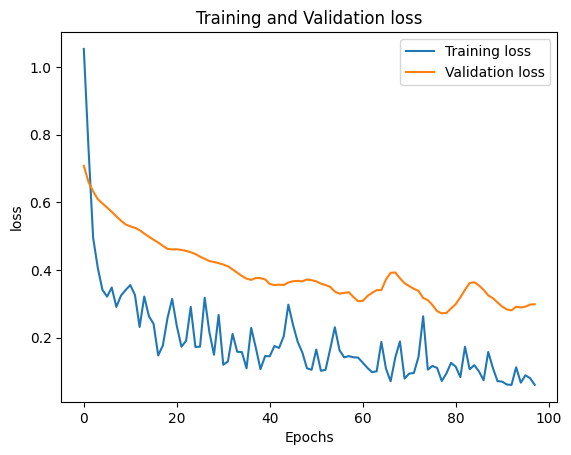

In [28]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.title('Training and Validation loss')
plt.legend()
plt.savefig(f"../imagenes/Training and Validation loss nn.png", bbox_inches="tight")
plt.show()

# Guardar modelo

In [29]:
best_model, model_path = save_best_model(models, "../churn_model/best_model")

Best model: nn_tf_model
Saved at: ..\churn_model\best_model.keras
